### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [19]:
data = pd.read_csv('coupons.csv')

In [20]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

2. Investigate the dataset for missing or problematic data.

In [22]:
missing = data.isnull().sum()
missing[missing > 0]

,0
car,12576
Bar,107
CoffeeHouse,217
CarryAway,151
RestaurantLessThan20,130
Restaurant20To50,189


In [23]:
data[['car','Bar','CoffeeHouse','CarryAway','RestaurantLessThan20','Restaurant20To50']].head()

,car,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50
0,NaN,never,never,NaN,4~8,1~3
1,NaN,never,never,NaN,4~8,1~3
2,NaN,never,never,NaN,4~8,1~3
3,NaN,never,never,NaN,4~8,1~3
4,NaN,never,never,NaN,4~8,1~3


3. Decide what to do about your missing data -- drop, replace, other...

In [24]:
# Drop 'car' column
data = data.drop(columns=['car'])

# Fill missing values with mode for specified columns
cols_to_fill = ['Bar', 'CoffeeHouse', 'CarryAway',
                'RestaurantLessThan20', 'Restaurant20To50']

for col in cols_to_fill:
    data[col] = data[col].fillna(data[col].mode())

4. What proportion of the total observations chose to accept the coupon?



In [28]:
# Proportion of customers who accepted the coupon (Y = 1)
acceptance_proportion = data['Y'].mean()*100
print(acceptance_proportion)

56.84326710816777


5. Use a bar plot to visualize the `coupon` column.

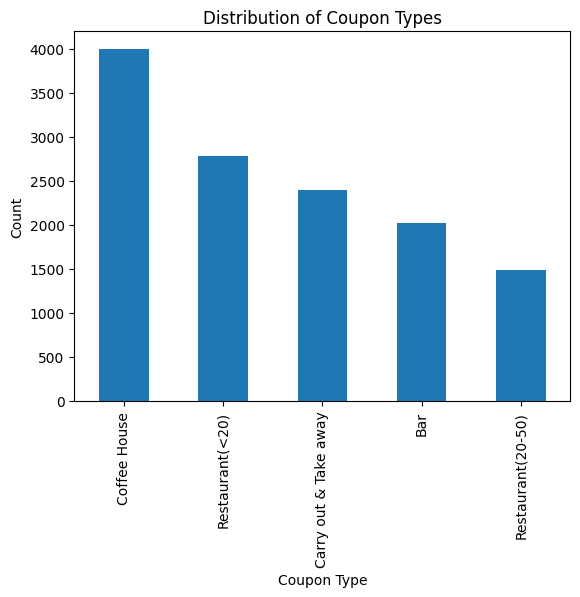

In [29]:
import matplotlib.pyplot as plt

# Count of each coupon type
coupon_counts = data['coupon'].value_counts()

# Bar plot
plt.figure()
coupon_counts.plot(kind='bar')

plt.xlabel('Coupon Type')
plt.ylabel('Count')
plt.title('Distribution of Coupon Types')

plt.show()

6. Use a histogram to visualize the temperature column.

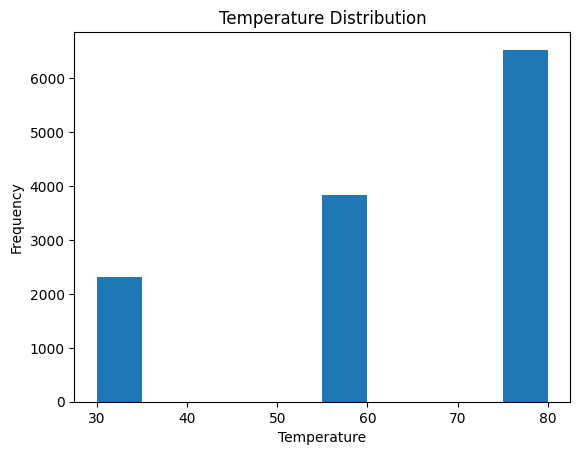

In [31]:
import matplotlib.pyplot as plt

# Histogram of temperature
plt.figure()
plt.hist(data['temperature'], bins=10)

plt.xlabel('Temperature')
plt.ylabel('Frequency')
plt.title('Temperature Distribution')

plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [33]:
# Create a new DataFrame containing only Bar coupons
bar_df = data[data['coupon'] == 'Bar']

# View first 5 rows
bar_df

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
9,No Urgent Place,Kid(s),Sunny,80,10AM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
13,Home,Alone,Sunny,55,6PM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,1,0,1
17,Work,Alone,Sunny,55,7AM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,1,0,1,0
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12663,No Urgent Place,Friend(s),Sunny,80,10PM,Bar,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12664,No Urgent Place,Friend(s),Sunny,55,10PM,Bar,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12667,No Urgent Place,Alone,Rainy,55,10AM,Bar,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12670,No Urgent Place,Partner,Rainy,55,6PM,Bar,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0


2. What proportion of bar coupons were accepted?


In [34]:
bar_acceptance_percentage = bar_df['Y'].mean() * 100
print(bar_acceptance_percentage)

41.00148735746158


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [36]:
# Compare acceptance rate based on bar visit frequency

# Group 1: 3 or fewer times a month
group_3_or_less = bar_df[bar_df['Bar'].isin(['never', 'less than 1', '1~3'])]
rate_3_or_less = group_3_or_less['Y'].mean()

# Group 2: More than 3 times a month
group_more_than_3 = bar_df[bar_df['Bar'].isin(['4~8', 'gt8'])]
rate_more_than_3 = group_more_than_3['Y'].mean()

print(rate_3_or_less)
print(rate_more_than_3)

0.33659331703341483
0.7688442211055276


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [42]:
# Drivers who go to a bar more than once a month
bar_more_than_once = bar_df['Bar'].isin(['1~3', '4~8', 'gt8'])

# Drivers over age 25
over_25 = bar_df['age'].isin(['26-30', '31-35', '36-40', '41-45',
                          '46-50', '50plus'])

# Group 1: Go to bar > once/month AND age > 25
group_target = bar_df[bar_more_than_once & over_25]
rate_target = group_target['Y'].mean()

# Group 2: All others
group_others = bar_df[~(bar_more_than_once & over_25)]
rate_others = group_others['Y'].mean()

print('Bar more than once and age >25:',rate_target)
print('Others:',rate_others)

Bar more than once and age >25: 0.6716417910447762
Others: 0.40102564102564103


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [45]:
# Drivers who go to bars more than once a month
bar_more_than_once = bar_df['Bar'].isin(['1~3', '4~8', 'gt8'])

# Passengers that are NOT a kid
not_kid_passenger = bar_df['passanger'] != 'Kid(s)'

# Occupations other than farming, fishing, or forestry
not_farming = bar_df['occupation'] != 'Farming Fishing & Forestry'

# Group 1: Meets all conditions
group_target = bar_df[bar_more_than_once & not_kid_passenger & not_farming]
rate_target = group_target['Y'].mean()

# Group 2: All others
group_others = bar_df[~(bar_more_than_once & not_kid_passenger & not_farming)]
rate_others = group_others['Y'].mean()

print('Drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry:',rate_target)
print('Others:',rate_others)

Drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry: 0.7132486388384754
Others: 0.296043656207367


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [44]:
# -------- Condition 1 --------
# Go to bars > once/month AND passenger not kid AND not widowed
cond1 = (
    bar_df['Bar'].isin(['1~3', '4~8', 'gt8']) &
    (bar_df['passanger'] != 'Kid(s)') &
    (bar_df['maritalStatus'] != 'Widowed')
)

rate1 = bar_df[cond1]['Y'].mean()


# -------- Condition 2 --------
# Go to bars > once/month AND age under 30
cond2 = (
    bar_df['Bar'].isin(['1~3', '4~8', 'gt8']) &
    bar_df['age'].isin(['below21', '21-25', '26-30'])
)

rate2 = bar_df[cond2]['Y'].mean()


# -------- Condition 3 --------
# Go to cheap restaurants > 4 times/month AND income < 50K
cond3 = (
    bar_df['RestaurantLessThan20'].isin(['4~8', 'gt8']) &
    bar_df['income'].isin([
        'Less than $12500',
        '$12500 - $24999',
        '$25000 - $37499',
        '$37500 - $49999'
    ])
)

rate3 = bar_df[cond3]['Y'].mean()


# -------- Print Results --------
print("Acceptance Rate - Condition 1 (Bar >1/month, No Kid Passenger, Not Widowed):", rate1)
print("Acceptance Rate - Condition 2 (Bar >1/month, Age < 30):", rate2)
print("Acceptance Rate - Condition 3 (Cheap Restaurant >4/month & Income < 50K):", rate3)

Acceptance Rate - Condition 1 (Bar >1/month, No Kid Passenger, Not Widowed): 0.7132486388384754
Acceptance Rate - Condition 2 (Bar >1/month, Age < 30): 0.4
Acceptance Rate - Condition 3 (Cheap Restaurant >4/month & Income < 50K): 0.45348837209302323


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

The analysis suggests that bar coupon acceptance is strongly associated with lifestyle and social context.

🔎 Key Observations

Frequent Bar Visitors Are Much More Likely to Accept

Bar > once/month & age >25 → 67.16%

Others → 40.10%

This shows habitual bar-goers are significantly more likely to accept bar coupons.

Social Context Matters a Lot

Bar >1/month + No Kid Passenger + Not Widowed → 71.32%

Others → much lower

Acceptance is highest when:

The driver is socially active

Not traveling with children

Not widowed

This suggests bar visits are socially motivated.

Occupation Also Plays a Role

Bar >1/month + No Kid Passenger + Not Farming/Fishing/Forestry → 71.32%

Others → 29.60%

This is a very large difference, indicating:

Certain lifestyle/occupation groups are much more responsive to bar promotions.

Age Under 30 Alone Is Not a Strong Factor

Bar >1/month + Age <30 → 40%

Younger age alone does not strongly increase acceptance.
Frequency of bar visits is more important than age.

Low Income + Cheap Restaurant Visitors

Acceptance → 45.35%

Income seems less influential compared to behavioral habits.

**Conclusion**

The analysis indicates that bar coupon acceptance is primarily driven by behavioral and social factors rather than basic demographics. Drivers who frequently visit bars are significantly more likely to accept bar coupons, especially when they are not traveling with children and are socially active. While age and income show some variation, they are not as strong predictors as bar-going frequency. Overall, lifestyle habits and current social context appear to be the strongest determinants of bar coupon acceptance.

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Overall acceptance rate
print("Overall Bar Coupon Acceptance Rate:", bar_df['Y'].mean())

# Acceptance by passenger
print("\nAcceptance by Passenger:")
print(bar_df.groupby('passanger')['Y'].mean())

# Acceptance by age
print("\nAcceptance by Age:")
print(bar_df.groupby('age')['Y'].mean())

# Acceptance by bar visit frequency
print("\nAcceptance by Bar Visit Frequency:")
print(bar_df.groupby('Bar')['Y'].mean())

Overall Bar Coupon Acceptance Rate: 0.41001487357461575

Acceptance by Passenger:
passanger
Alone        0.407500
Friend(s)    0.557864
Kid(s)       0.208738
Partner      0.390511
Name: Y, dtype: float64

Acceptance by Age:
age
21         0.505995
26         0.488608
31         0.368732
36         0.301435
41         0.432584
46         0.348624
50plus     0.296820
below21    0.413793
Name: Y, dtype: float64

Acceptance by Bar Visit Frequency:
Bar
1~3      0.647355
4~8      0.780000
gt8      0.734694
less1    0.443860
never    0.187952
Name: Y, dtype: float64


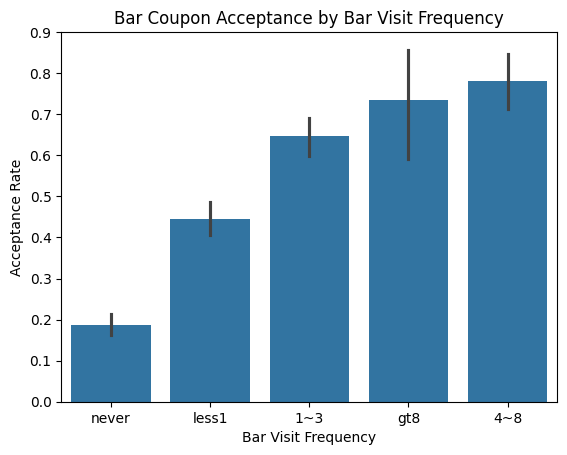

In [53]:
plt.figure()
sns.barplot(x='Bar', y='Y', data=bar_df)

plt.title("Bar Coupon Acceptance by Bar Visit Frequency")
plt.xlabel("Bar Visit Frequency")
plt.ylabel("Acceptance Rate")

plt.show()

**Findings – Bar Coupon Analysis**

Overall Acceptance

The overall bar coupon acceptance rate is 41.0%, indicating moderate interest but clear room for targeted improvement.

2️⃣ Bar Visit Frequency (Strongest Predictor)

Acceptance increases dramatically with bar visit frequency:

Never → 18.8%

Less than 1/month → 44.4%

1–3/month → 64.7%

4–8/month → 78.0%

More than 8/month → 73.5%

📌 Insight: The more frequently a driver visits bars, the significantly higher the probability of accepting a bar coupon. Behavioral habit is the strongest determinant.

3️⃣ Passenger Type

Friend(s) → 55.8%

Alone → 40.8%

Partner → 39.1%

Kid(s) → 20.9%

📌 Insight: Drivers traveling with friends are most likely to accept bar coupons. Acceptance drops sharply when traveling with children.

4️⃣ Age Trends

Higher acceptance among:

Age 21 → 50.6%

Age 26 → 48.9%

Lower acceptance among:

Age 36 → 30.1%

50+ → 29.7%

📌 Insight: Younger adults are more responsive to bar promotions, while older drivers show lower interest.


**Actionable Items & Recommendations**

✅ 1. Behavioral Targeting (Highest Priority)

Focus bar coupon promotions on:

Drivers who visit bars at least 1–3 times per month

Especially those visiting 4+ times per month

This segment shows acceptance rates above 65–78%.

✅ 2. Context-Based Targeting

Avoid sending bar coupons when:

Passenger = Kid(s)

Instead, prioritize:

Passenger = Friend(s)

Passenger = Alone (secondary target)

✅ 3. Age-Based Refinement

Prioritize drivers aged:

21–30

Reduce targeting budget for:

Age 36+

50+

✅ 4. Dynamic Coupon Triggering

Implement smart coupon delivery rules:

IF:

Bar frequency ≥ 1–3/month

Passenger ≠ Kid(s)

Age < 35

THEN:

High-priority coupon push

🏁 Strategic Business Insight

Bar coupon acceptance is primarily driven by lifestyle behavior and social context, not just demographics. The strongest conversion opportunity lies among socially active, frequent bar visitors traveling without children.

Targeted delivery using behavioral filters can significantly increase coupon redemption rates while reducing wasted promotions.

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

Step 1: Create Coffee House DataFrame

In [46]:
coffee_df = data[data['coupon'] == 'Coffee House']
coffee_df.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
12,No Urgent Place,Kid(s),Sunny,55,6PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
15,Home,Alone,Sunny,80,6PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0


Step 2: Overall Acceptance Rate

In [47]:
coffee_acceptance = coffee_df['Y'].mean()
print("Overall Coffee Coupon Acceptance Rate:", coffee_acceptance)

Overall Coffee Coupon Acceptance Rate: 0.49924924924924924


Step 3: Acceptance by Passenger Type

In [48]:
passenger_acceptance = coffee_df.groupby('passanger')['Y'].mean()

print("Acceptance Rate by Passenger Type:")
print(passenger_acceptance)

Acceptance Rate by Passenger Type:
passanger
Alone        0.437943
Friend(s)    0.596906
Kid(s)       0.483092
Partner      0.570492
Name: Y, dtype: float64


Step 4: Acceptance by Age

In [49]:
age_acceptance = coffee_df.groupby('age')['Y'].mean()

print("Acceptance Rate by Age:")
print(age_acceptance)

Acceptance Rate by Age:
age
21         0.524349
26         0.514828
31         0.476726
36         0.467662
41         0.501538
46         0.513636
50plus     0.420183
below21    0.696774
Name: Y, dtype: float64


Step 5: Acceptance by Time of Day

In [50]:
time_acceptance = coffee_df.groupby('time')['Y'].mean()

print("Acceptance Rate by Time of Day:")
print(time_acceptance)

Acceptance Rate by Time of Day:
time
10AM    0.640712
10PM    0.424242
2PM     0.547859
6PM     0.412626
7AM     0.445783
Name: Y, dtype: float64


Step 6: Acceptance by Coffee Visiting Frequency

In [51]:
coffee_freq_acceptance = coffee_df.groupby('CoffeeHouse')['Y'].mean()

print("Acceptance Rate by Coffee House Visit Frequency:")
print(coffee_freq_acceptance)

Acceptance Rate by Coffee House Visit Frequency:
CoffeeHouse
1~3      0.647793
4~8      0.685874
gt8      0.657895
less1    0.481860
never    0.188781
Name: Y, dtype: float64


**Conclusion – Coffee House Coupon Investigation**

The analysis shows that approximately 49.9% of coffee house coupons were accepted, indicating moderate overall interest. However, acceptance varies significantly based on social context, age, time of day, and coffee consumption habits.

Drivers traveling with friends (59.7%) or partners (57.0%) were more likely to accept coffee coupons compared to those driving alone (43.8%). This suggests that coffee purchases are often socially motivated.

Age also plays an important role. Acceptance was highest among drivers below 21 (69.7%), while individuals aged 50 and above (42.0%) were the least likely to accept. This indicates that younger drivers are more responsive to coffee promotions.

Time of day strongly influenced decisions. Acceptance peaked at 10AM (64.1%), which aligns with typical coffee consumption patterns. Acceptance dropped significantly in the evening (6PM and 10PM), suggesting coffee coupons are more effective earlier in the day.

The strongest predictor was coffee house visiting frequency. Drivers who visit coffee houses regularly (1–3, 4–8, or more than 8 times per month) showed very high acceptance rates (65–69%), while those who never visit had a very low acceptance rate (18.9%). This confirms that habitual behavior is the most powerful determinant of coupon acceptance.

**Overall Hypothesis**

Coffee house coupon acceptance is primarily driven by existing consumption habits, younger age groups, social travel context, and morning timing. Frequent coffee drinkers, especially younger drivers traveling with friends or partners in the morning, are the most likely to accept coffee coupons.

Statistical Summary (Coffee Coupons)

In [54]:
# Overall acceptance rate
print("Overall Coffee Coupon Acceptance Rate:", coffee_df['Y'].mean())

# Acceptance by passenger
print("\nAcceptance by Passenger:")
print(coffee_df.groupby('passanger')['Y'].mean())

# Acceptance by age
print("\nAcceptance by Age:")
print(coffee_df.groupby('age')['Y'].mean())

# Acceptance by time
print("\nAcceptance by Time:")
print(coffee_df.groupby('time')['Y'].mean())

# Acceptance by coffee visit frequency
print("\nAcceptance by Coffee Visit Frequency:")
print(coffee_df.groupby('CoffeeHouse')['Y'].mean())

Overall Coffee Coupon Acceptance Rate: 0.49924924924924924

Acceptance by Passenger:
passanger
Alone        0.437943
Friend(s)    0.596906
Kid(s)       0.483092
Partner      0.570492
Name: Y, dtype: float64

Acceptance by Age:
age
21         0.524349
26         0.514828
31         0.476726
36         0.467662
41         0.501538
46         0.513636
50plus     0.420183
below21    0.696774
Name: Y, dtype: float64

Acceptance by Time:
time
10AM    0.640712
10PM    0.424242
2PM     0.547859
6PM     0.412626
7AM     0.445783
Name: Y, dtype: float64

Acceptance by Coffee Visit Frequency:
CoffeeHouse
1~3      0.647793
4~8      0.685874
gt8      0.657895
less1    0.481860
never    0.188781
Name: Y, dtype: float64


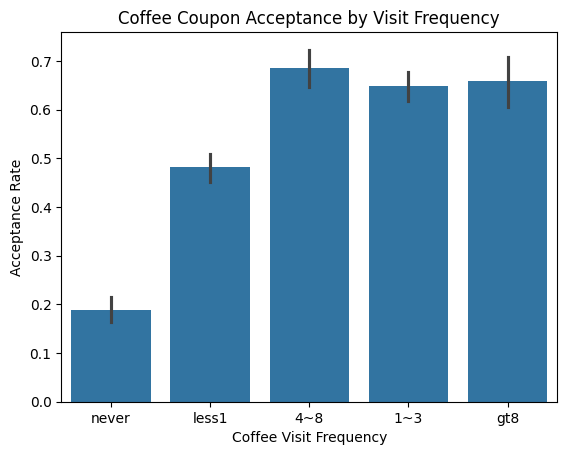

In [55]:
plt.figure()
sns.barplot(x='CoffeeHouse', y='Y', data=coffee_df)

plt.title("Coffee Coupon Acceptance by Visit Frequency")
plt.xlabel("Coffee Visit Frequency")
plt.ylabel("Acceptance Rate")

plt.show()

**Findings – Coffee Coupon Analysis**

1️⃣ Overall Acceptance

The overall coffee coupon acceptance rate is 49.9%, which is higher than the bar coupon rate (41%). This suggests coffee promotions have broader appeal.

2️⃣ Coffee Visit Frequency (Strongest Predictor)

Acceptance increases significantly with frequency:

Never → 18.9%

Less than 1/month → 48.2%

1–3/month → 64.8%

4–8/month → 68.6%

More than 8/month → 65.8%

📌 Insight: Frequent coffee drinkers are far more likely to accept coupons. Behavioral habit is again the strongest determinant.

3️⃣ Passenger Type

Friend(s) → 59.7%

Partner → 57.0%

Kid(s) → 48.3%

Alone → 43.8%

📌 Insight: Coffee coupons perform best in social settings (friends or partner). Unlike bar coupons, traveling with kids does not drastically reduce acceptance.

4️⃣ Age Trends

Highest acceptance:

Below 21 → 69.7%

Ages 21–26 → ~51–52%

Lowest acceptance:

50+ → 42.0%

📌 Insight: Younger drivers are much more responsive to coffee promotions.

5️⃣ Time of Day (Very Important)

10AM → 64.1% (highest)

2PM → 54.8%

6PM → 41.3%

10PM → 42.4%

📌 Insight: Morning is the optimal time for coffee coupon delivery. Evening performance drops significantly.

**Actionable Items & Recommendations**

✅ 1. Target Frequent Coffee Buyers

Prioritize users visiting coffee houses 1+ times per month, especially those visiting 4–8 times monthly.

✅ 2. Morning-Based Coupon Strategy

Push coffee coupons primarily around 10AM.
Reduce promotion frequency during evening and late-night hours.

✅ 3. Youth-Focused Campaigns

Focus marketing budget on:

Under 30 age group

Especially under 21 segment

✅ 4. Social Context Optimization

Prioritize sending coffee coupons when:

Passenger = Friend(s)

Passenger = Partner

✅ 5. Avoid Low-Probability Segments

Minimize targeting:

Drivers who never visit coffee houses

Older (50+) low-frequency customers

🏁 Strategic Business Insight

Coffee coupon acceptance is driven by habitual consumption, morning timing, and social context. Unlike bar coupons, coffee promotions appeal to a wider demographic but are highly time-sensitive. Behavioral targeting combined with time-of-day optimization can substantially improve conversion rates.